<a href="https://colab.research.google.com/github/HelloSamved/LLM-from-basics/blob/master/linear%20regression%20project/regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
!pip install pandas numpy matplotlib seaborn tensorflow

In [29]:
import pandas as pd
import numpy
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [30]:
url = 'https://raw.githubusercontent.com/HelloSamved/LLM-from-basics/master/linear%20regression%20project/insurance.csv'
df = pd.read_csv(url)

In [11]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


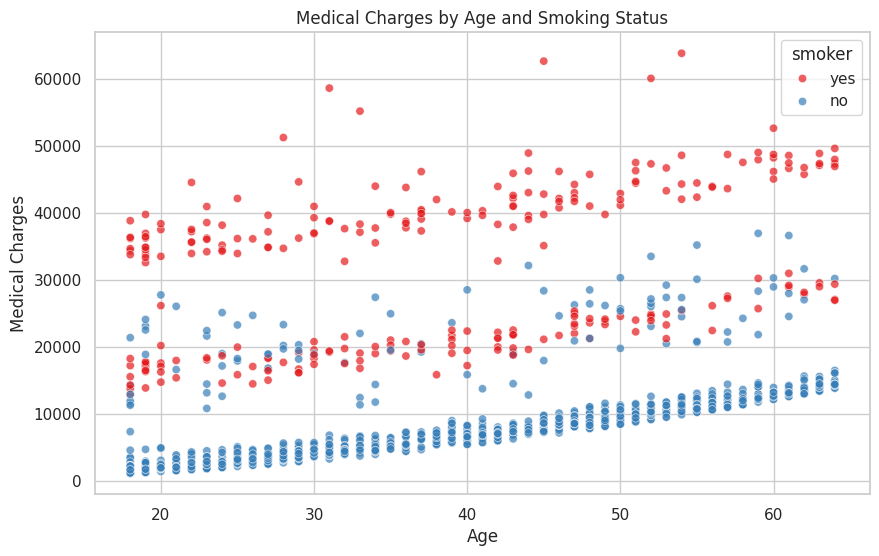

In [15]:
sns.set_theme(style='whitegrid')

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', palette='Set1', alpha=0.7)
plt.title('Medical Charges by Age and Smoking Status')
plt.xlabel('Age')
plt.ylabel('Medical Charges')
plt.show()

In [32]:
df_encoded= pd.get_dummies(df,columns=['sex','smoker','region'], drop_first=True)
display(df_encoded.head())

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,False,True,False,False,True
1,18,33.770,1,1725.55230,True,False,False,True,False
2,28,33.000,3,4449.46200,True,False,False,True,False
3,33,22.705,0,21984.47061,True,False,True,False,False
4,32,28.880,0,3866.85520,True,False,True,False,False


In [58]:
x= df_encoded.drop('charges', axis=1)
y= df_encoded['charges']

In [60]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=0.2, random_state=42)

print(f"Training data size: {x_train.shape[0]} rows")
print(f"Testing data size: {x_test.shape[0]} rows")

Training data size: 1070 rows
Testing data size: 268 rows


In [61]:
from sklearn.preprocessing import StandardScaler

# Create the scaler tool
scaler = StandardScaler()

# "Fit" it to the training data and transform it
x_train_scaled = scaler.fit_transform(x_train)

# Only "transform" the test data (using the rules learned from the training data)
xtest_scaled = scaler.transform(x_test)

In [63]:
# Create a blank, sequential network
model = models.Sequential()

# Add one single layer
model.add(layers.Dense(units=1, input_shape=[x_train_scaled.shape[1]]))

# View the blueprint of our network
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9 (36.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

In [64]:
# Compile the rules for learning
model.compile(
    # The optimizer updates the weights to fix mistakes. We use a learning rate of 100.0
    # so it takes big enough steps to reach tens of thousands of dollars quickly!
    optimizer=tf.keras.optimizers.Adam(learning_rate=100.0),

    # The Loss Function: How it calculates its "wrongness"
    loss='mean_squared_error',

    # An easier metric for us to read: "How far off are we in actual dollars?"
    metrics=['mean_absolute_error']
)

In [79]:
import numpy as np

# Convert x_train_scaled and y_train to tf.float32 and reshape y_train
x_train_scaled_float32 = x_train_scaled.astype(np.float32)
y_train_reshaped_float32 = y_train.values.reshape(-1, 1).astype(np.float32)

# Manual split for training and validation data (90% for validation, 10% for training)
num_samples = x_train_scaled_float32.shape[0]
validation_split_ratio = 0.9
val_split_index = int(num_samples * validation_split_ratio)

# Training data (the remaining 10%)
x_train_subset = x_train_scaled_float32[val_split_index:]
y_train_subset = y_train_reshaped_float32[val_split_index:]

# Validation data (the first 90%)
x_val = x_train_scaled_float32[:val_split_index]
y_val = y_train_reshaped_float32[:val_split_index]

history= model.fit(
    x_train_subset,
    y_train_subset,
    epochs=100,
    validation_data=(x_val, y_val), # Pass validation data explicitly
    verbose=1
)

Epoch 1/100
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 39954384.0000 - mean_absolute_error: 4807.4092

KeyError: Input Parameters:
  iterator (POSITIONAL_OR_KEYWORD): IteratorSpec((TensorSpec(shape=(None, 8), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)),)
Output Type:
  None
Captures:
  None